# Geo-SLM Chart Analysis - Pipeline Overview

| Version | Date | Author | Description |
| --- | --- | --- | --- |
| 2.0.0 | 2026-01-26 | That Le | Complete pipeline documentation |

---

## Project Introduction

**Geo-SLM Chart Analysis** is a **hybrid AI system** for extracting structured data from chart images.

### Core Philosophy
> "Accuracy through Hybrid Intelligence: Use Deep Learning for perception, Geometry for precision, and SLM for reasoning."

### Technology Stack

| Component | Technology | Purpose |
| --- | --- | --- |
| Object Detection | YOLOv8/v11 | Detect chart regions in documents |
| Classification | ResNet-18 | Classify chart types (94.66% accuracy) |
| OCR | PaddleOCR/EasyOCR | Extract text from charts |
| Geometric Analysis | OpenCV + NumPy | Precise value extraction |
| Reasoning | Gemini API / Local SLM | OCR correction & semantic reasoning |

---

## The 5-Stage Pipeline Architecture

```
Input (PDF/Image)
       |
       v
+---------------------+     +---------------------------+
| STAGE 1: INGESTION  | --> | Output: Stage1Output      |
| - Load PDF/Image    |     | - session: SessionInfo    |
| - Convert to images |     | - images: List[CleanImage]|
| - Quality validation|     | - warnings: List[str]     |
+---------------------+     +---------------------------+
       |
       v
+---------------------+     +---------------------------+
| STAGE 2: DETECTION  | --> | Output: Stage2Output      |
| - YOLO inference    |     | - session: SessionInfo    |
| - Crop chart regions|     | - charts: List[Detected   |
| - Filter by conf    |     |   Chart]                  |
+---------------------+     +---------------------------+
       |
       v
+---------------------+     +---------------------------+
| STAGE 3: EXTRACTION | --> | Output: Stage3Output      |
| - ResNet-18 classify|     | - session: SessionInfo    |
| - OCR text extract  |     | - metadata: List[Raw      |
| - Element detection |     |   Metadata]               |
| - Geometric analysis|     |                           |
+---------------------+     +---------------------------+
       |
       v
+---------------------+     +---------------------------+
| STAGE 4: REASONING  | --> | Output: Stage4Output      |
| - OCR correction    |     | - session: SessionInfo    |
| - Value mapping     |     | - charts: List[Refined    |
| - Legend association|     |   ChartData]              |
| - Description gen   |     |                           |
+---------------------+     +---------------------------+
       |
       v
+---------------------+     +---------------------------+
| STAGE 5: REPORTING  | --> | Output: PipelineResult    |
| - Schema validation |     | - session: SessionInfo    |
| - Insight generation|     | - charts: List[Final      |
| - Output formatting |     |   ChartResult]            |
+---------------------+     | - summary: str            |
       |                    +---------------------------+
       v
Output (JSON + Report)
```

---

## Notebook Index

| Notebook | Stage | Description | Status |
| --- | --- | --- | --- |
| `00_quick_start.ipynb` | Overview | This file - Pipeline overview | CURRENT |
| `01_stage1_ingestion.ipynb` | Stage 1 | PDF/Image loading & normalization | COMPLETE |
| `02_stage2_detection.ipynb` | Stage 2 | YOLO chart detection | COMPLETE |
| `03_stage3_extraction.ipynb` | Stage 3 | Classification, OCR, Geometry | COMPLETE |
| `04_stage4_reasoning.ipynb` | Stage 4 | SLM/Gemini reasoning | IN PROGRESS |

---

## Configuration

**IMPORTANT**: Set `EXECUTE_EXAMPLES = True` to run actual code examples.
Keep it `False` for documentation-only mode (no API calls, no heavy processing).

In [1]:
# ============================================================================
# EXECUTION CONTROL FLAG
# ============================================================================
# Set to True to execute actual examples (API calls, model loading, etc.)
# Set to False for documentation-only mode (safe for reading/review)
# ============================================================================

EXECUTE_EXAMPLES = True  # <-- Change to True to run examples

print(f"Execution mode: {'ACTIVE - Will run examples' if EXECUTE_EXAMPLES else 'DOCUMENTATION ONLY - No heavy tasks'}")

Execution mode: ACTIVE - Will run examples


In [2]:
# ============================================================================
# ENVIRONMENT SETUP (Always runs - lightweight)
# ============================================================================
import sys
from pathlib import Path

# Add project root to Python path
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")
print(f"Python version: {sys.version.split()[0]}")

# Verify project structure
required_dirs = [
    PROJECT_ROOT / "src" / "core_engine",
    PROJECT_ROOT / "data",
    PROJECT_ROOT / "config",
    PROJECT_ROOT / "models" / "weights",
]
print("\nProject structure check:")
for d in required_dirs:
    status = "OK" if d.exists() else "MISSING"
    print(f"  [{status}] {d.relative_to(PROJECT_ROOT)}")

Project root: d:\elix\chart_analysis_ai_v3
Python version: 3.12.10

Project structure check:
  [OK] src\core_engine
  [OK] data
  [OK] config
  [OK] models\weights


---

## Schema Definitions Reference

All schemas are defined in `src/core_engine/schemas/`. Here's a quick reference:

### Common Types (`schemas/common.py`)

```python
class BoundingBox(BaseModel):
    """Bounding box coordinates (pixel space)."""
    x_min: int  # Left edge
    y_min: int  # Top edge  
    x_max: int  # Right edge
    y_max: int  # Bottom edge
    confidence: float  # Detection confidence [0-1]

class Point(BaseModel):
    """2D point in pixel coordinates."""
    x: int
    y: int

class Color(BaseModel):
    """RGB color representation."""
    r: int  # 0-255
    g: int  # 0-255
    b: int  # 0-255

class SessionInfo(BaseModel):
    """Processing session metadata."""
    session_id: str           # Unique identifier
    created_at: datetime      # Timestamp
    source_file: Path         # Input file path
    config_hash: str          # For reproducibility
```

### Chart Types (`schemas/enums.py`)

```python
class ChartType(str, Enum):
    BAR = "bar"           # Vertical/horizontal bar charts
    LINE = "line"         # Line charts with data points
    PIE = "pie"           # Pie/donut charts
    SCATTER = "scatter"   # Scatter plots
    AREA = "area"         # Area charts
    HISTOGRAM = "histogram"
    BOX = "box"           # Box plots
    HEATMAP = "heatmap"
    UNKNOWN = "unknown"   # Unclassified
```

---

## Quick Demo: Stage 3 Extraction

Found 5 sample images


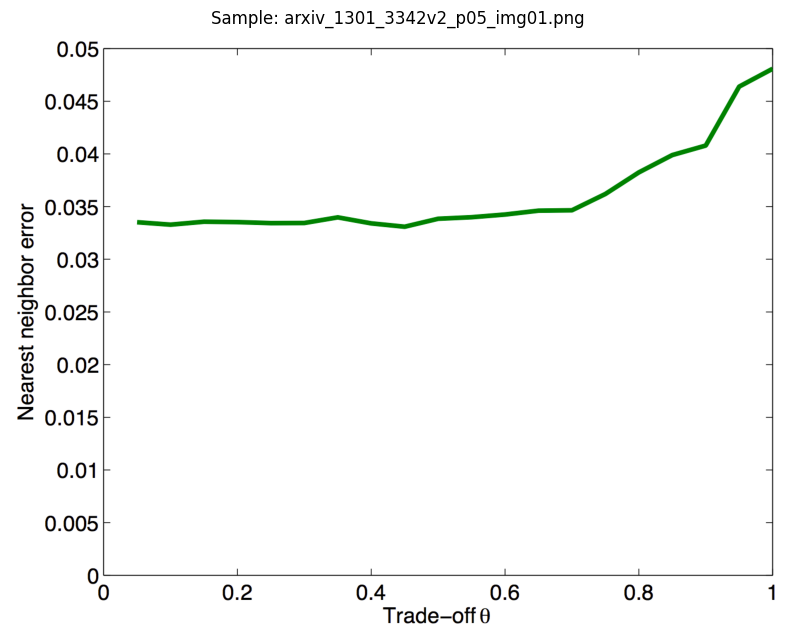

In [3]:
# ============================================================================
# DEMO: Load and Display Sample Chart
# ============================================================================
if EXECUTE_EXAMPLES:
    import cv2
    import numpy as np
    import matplotlib.pyplot as plt
    from PIL import Image
    
    # Find sample images
    sample_dirs = [
        PROJECT_ROOT / "data" / "academic_dataset" / "images",
        PROJECT_ROOT / "data" / "samples",
    ]
    
    sample_images = []
    for sample_dir in sample_dirs:
        if sample_dir.exists():
            sample_images.extend(list(sample_dir.glob("*.png"))[:5])
            sample_images.extend(list(sample_dir.glob("*.jpg"))[:5])
    
    print(f"Found {len(sample_images)} sample images")
    
    if sample_images:
        # Display first sample
        image_path = sample_images[0]
        img = Image.open(image_path)
        
        plt.figure(figsize=(10, 8))
        plt.imshow(img)
        plt.title(f"Sample: {image_path.name}")
        plt.axis('off')
        plt.show()
else:
    print("[SKIPPED] Set EXECUTE_EXAMPLES = True to run this demo")
    print("\nExpected behavior:")
    print("  - Loads sample images from data/academic_dataset/images/")
    print("  - Displays first chart image using matplotlib")

In [4]:
# ============================================================================
# DEMO: Stage 3 Extraction
# ============================================================================
if EXECUTE_EXAMPLES:
    from src.core_engine.stages.s3_extraction import Stage3Extraction, ExtractionConfig
    
    # Initialize Stage 3 with configuration
    # NOTE: This loads the ResNet-18 model (~43MB)
    config = ExtractionConfig(
        use_ml_classifier=True,        # Use ResNet-18 (94.66% accuracy)
        enable_ocr=True,               # Enable OCR text extraction
        enable_element_detection=True, # Detect bars, lines, etc.
        use_color_segmentation=True,   # K-Means color segmentation
    )
    stage3 = Stage3Extraction(config=config)
    
    print("Stage 3 initialized with:")
    print(f"  - ML Classifier: {config.use_ml_classifier}")
    print(f"  - OCR Engine: {config.ocr_engine}")
    print(f"  - Color Segmentation: {config.use_color_segmentation}")
    
    # Process sample image
    if sample_images:
        img_bgr = cv2.imread(str(sample_images[0]))
        result = stage3.process_image(img_bgr, chart_id="demo_chart")
        
        print("\n" + "=" * 50)
        print("Stage 3 Extraction Results")
        print("=" * 50)
        print(f"Chart Type: {result.chart_type.value}")
        print(f"OCR Texts: {len(result.texts)}")
        print(f"Elements: {len(result.elements)}")
        
        # Show first few texts
        print("\nExtracted Texts (first 5):")
        for t in result.texts[:5]:
            print(f"  [{t.role or 'unknown':10}] {t.text}")
else:
    print("[SKIPPED] Set EXECUTE_EXAMPLES = True to run Stage 3 demo")
    print("\nExpected behavior:")
    print("  - Loads ResNet-18 classifier model")
    print("  - Classifies chart type (bar, line, pie, etc.)")
    print("  - Extracts text using PaddleOCR")
    print("  - Detects chart elements (bars, points, etc.)")

Stage 3 initialized with:
  - ML Classifier: True
  - OCR Engine: easyocr
  - Color Segmentation: True


Using CPU. Note: This module is much faster with a GPU.



Stage 3 Extraction Results
Chart Type: line
OCR Texts: 17
Elements: 57

Extracted Texts (first 5):
  [unknown   ] 0.05
  [y_tick    ] 0.045
  [y_tick    ] 0.04
  [y_tick    ] 0.035
  [y_axis_label] 8


---

## Pipeline Error Handling Strategy

The pipeline implements **graceful degradation**:

| Stage | Error Type | Severity | Action |
| --- | --- | --- | --- |
| S1 | File not found | CRITICAL | Abort pipeline |
| S1 | Low quality image | WARNING | Skip with warning |
| S2 | No detections | NORMAL | Return empty result |
| S2 | Model load failure | CRITICAL | Abort |
| S3 | OCR failure | WARNING | Continue with empty text |
| S3 | Classification uncertain | WARNING | Default to "unknown" |
| S4 | SLM/API timeout | WARNING | Use rule-based fallback |
| S5 | Validation failure | WARNING | Return unvalidated result |

### Result Status Codes

| Status | Meaning |
| --- | --- |
| `completed` | All stages passed successfully |
| `partial` | Some stages used fallback methods |
| `empty` | No charts detected (valid result) |
| `failed` | Critical stage failed |

---

## Project Directory Structure

```
chart_analysis_ai_v3/
|
+-- config/                  # Configuration files
|   +-- base.yaml            # Base configuration
|   +-- models.yaml          # Model paths & thresholds
|   +-- pipeline.yaml        # Stage configuration
|
+-- data/
|   +-- academic_dataset/    # Arxiv chart images (2,852 charts)
|   +-- raw/                 # Input files
|   +-- processed/           # Pipeline outputs
|   +-- cache/               # Intermediate results
|
+-- src/core_engine/         # Core AI Engine
|   +-- pipeline.py          # Main orchestrator
|   +-- schemas/             # Pydantic data models
|   +-- stages/              # Pipeline stages (s1-s5)
|   |   +-- s1_ingestion.py
|   |   +-- s2_detection.py
|   |   +-- s3_extraction/   # Complex stage (multiple modules)
|   |   +-- s4_reasoning.py
|   |   +-- s5_reporting.py
|
+-- models/weights/          # Trained model files
|   +-- resnet18_chart_classifier.onnx  # 43MB, 94.66% accuracy
|
+-- notebooks/               # This directory
+-- scripts/                 # Utility scripts
+-- tests/                   # Unit tests (129 test cases)
```

---

## Next Steps

Continue exploring the pipeline in detail:

1. **Stage 1**: [01_stage1_ingestion.ipynb](01_stage1_ingestion.ipynb) - PDF/Image loading
2. **Stage 2**: [02_stage2_detection.ipynb](02_stage2_detection.ipynb) - YOLO detection  
3. **Stage 3**: [03_stage3_extraction.ipynb](03_stage3_extraction.ipynb) - Full extraction
4. **Stage 4**: [04_stage4_reasoning.ipynb](04_stage4_reasoning.ipynb) - SLM reasoning

### Current Development Status

| Stage | Implementation | Testing | Key Metrics |
| --- | --- | --- | --- |
| Stage 1 | COMPLETE | COMPLETE | PyMuPDF, 150 DPI |
| Stage 2 | COMPLETE | COMPLETE | YOLOv8, 85%+ mAP |
| Stage 3 | COMPLETE | COMPLETE | ResNet-18, 94.66% accuracy |
| Stage 4 | IN PROGRESS | PARTIAL | Gemini API integration |
| Stage 5 | TODO | - | Output formatting |

# Geo-SLM Chart Analysis - Quick Start

| Version | Date | Author | Description |
| --- | --- | --- | --- |
| 1.0.0 | 2026-01-25 | That Le | Quick start notebook |
| 1.1.0 | 2026-01-26 | That Le | Updated for ResNet-18 & Stage 4 |

## Overview

This notebook provides a quick introduction to the Geo-SLM Chart Analysis pipeline.

### The 5-Stage Pipeline

```
Input (PDF/Image)
    |
    v
+-------------------+
| Stage 1: Ingest   | --> Load, Convert, Normalize
+-------------------+
    |
    v
+-------------------+
| Stage 2: Detect   | --> YOLO Detection, Crop Charts
+-------------------+
    |
    v
+-------------------+
| Stage 3: Extract  | --> ResNet-18 Classification, OCR, Geometry
+-------------------+
    |
    v
+-------------------+
| Stage 4: Reason   | --> Gemini API / SLM Reasoning
+-------------------+
    |
    v
+-------------------+
| Stage 5: Report   | --> Output Generation [PLANNED]
+-------------------+
```

### Key Updates (v3.0)
- ResNet-18 Classifier: **94.66% accuracy** (vs 37.5% baseline)
- K-Means Element Detection: Better stacked bar/pie detection
- Gemini API Integration: Stage 4 reasoning

## 1. Setup

In [5]:
# Standard library
import sys
from pathlib import Path

# Add project root to path
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

# Third-party
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Local imports - now import from src.core_engine
from src.core_engine.stages.s3_extraction import Stage3Extraction, ExtractionConfig

print("Setup complete!")
print("\nPipeline Components:")
print("  - Stage 3: ResNet-18 Classifier + K-Means Detection")

Project root: d:\elix\chart_analysis_ai_v3
Setup complete!

Pipeline Components:
  - Stage 3: ResNet-18 Classifier + K-Means Detection


## 2. Load Sample Chart Image

Found 3121 sample images

Using: arxiv_1301_3342v2_p05_img01.png


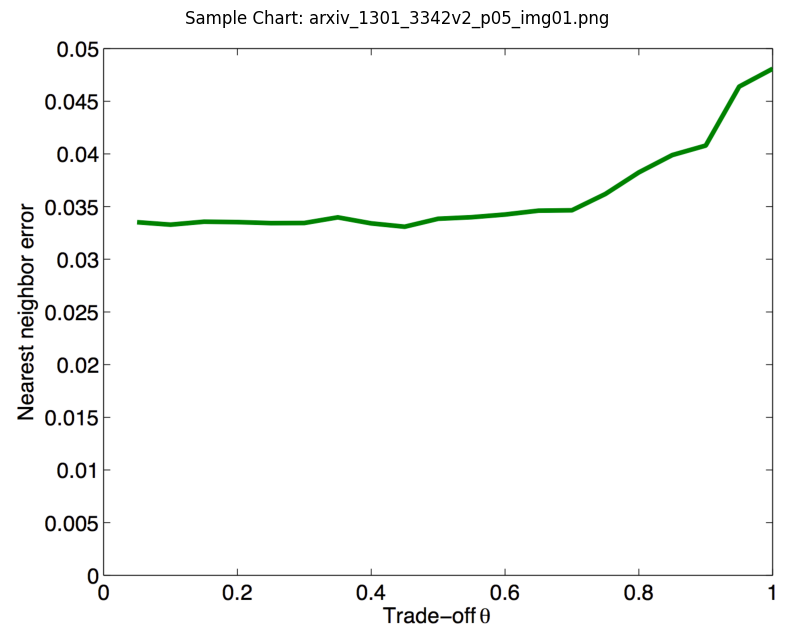

In [6]:
# Find sample images
sample_dirs = [
    PROJECT_ROOT / "data" / "academic_dataset" / "images",
    PROJECT_ROOT / "data" / "samples",
]

sample_images = []
for sample_dir in sample_dirs:
    if sample_dir.exists():
        sample_images.extend(list(sample_dir.glob("*.png")))
        sample_images.extend(list(sample_dir.glob("*.jpg")))

print(f"Found {len(sample_images)} sample images")

# Select first image
if sample_images:
    image_path = sample_images[0]
    print(f"\nUsing: {image_path.name}")
    
    # Display image
    img = Image.open(image_path)
    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.title(f"Sample Chart: {image_path.name}")
    plt.axis('off')
    plt.show()
else:
    print("No sample images found. Please add images to data/samples/")
    image_path = None

## 3. Run Stage 3: Extraction

In [7]:
if image_path:
    # Initialize Stage 3 with ResNet-18 classifier (NEW!)
    config = ExtractionConfig(
        use_ml_classifier=True,      # Use ResNet-18 (94.66% accuracy)
        enable_ocr=True,
        enable_element_detection=True,
        use_color_segmentation=True,  # K-Means for better element detection
        enable_vectorization=False,   # Disable for quick test
    )
    stage3 = Stage3Extraction(config=config)
    
    # Load image and process directly
    img_bgr = cv2.imread(str(image_path))
    
    # Use process_image() for direct image processing
    result = stage3.process_image(img_bgr, chart_id=image_path.stem)
    
    # Find title from texts
    title_texts = [t for t in result.texts if t.role == "title"]
    title = title_texts[0].text if title_texts else "No title detected"
    
    print("=" * 50)
    print("Stage 3 Extraction Results")
    print("=" * 50)
    print(f"Chart Type: {result.chart_type.value}")
    print(f"Title: {title}")
    print(f"OCR Texts: {len(result.texts)}")
    print(f"Elements: {len(result.elements)}")
else:
    print("No image to process")

Using CPU. Note: This module is much faster with a GPU.


Stage 3 Extraction Results
Chart Type: line
Title: No title detected
OCR Texts: 17
Elements: 57


## 4. View Extraction Results

In [8]:
if image_path and result:
    # Display detected texts
    print("=" * 50)
    print("OCR Results")
    print("=" * 50)
    for text in result.texts[:10]:  # Show first 10
        print(f"  [{text.role or 'unknown':10}] {text.text}")
    
    print(f"\n... and {len(result.texts) - 10} more" if len(result.texts) > 10 else "")

OCR Results
  [unknown   ] 0.05
  [y_tick    ] 0.045
  [y_tick    ] 0.04
  [y_tick    ] 0.035
  [y_axis_label] 8
  [y_axis_label] 0.03
  [y_axis_label] 1
  [y_axis_label] 0.025
  [y_axis_label] 0.02
  [y_axis_label] 0.015

... and 7 more


## 5. Visualize Processing Steps

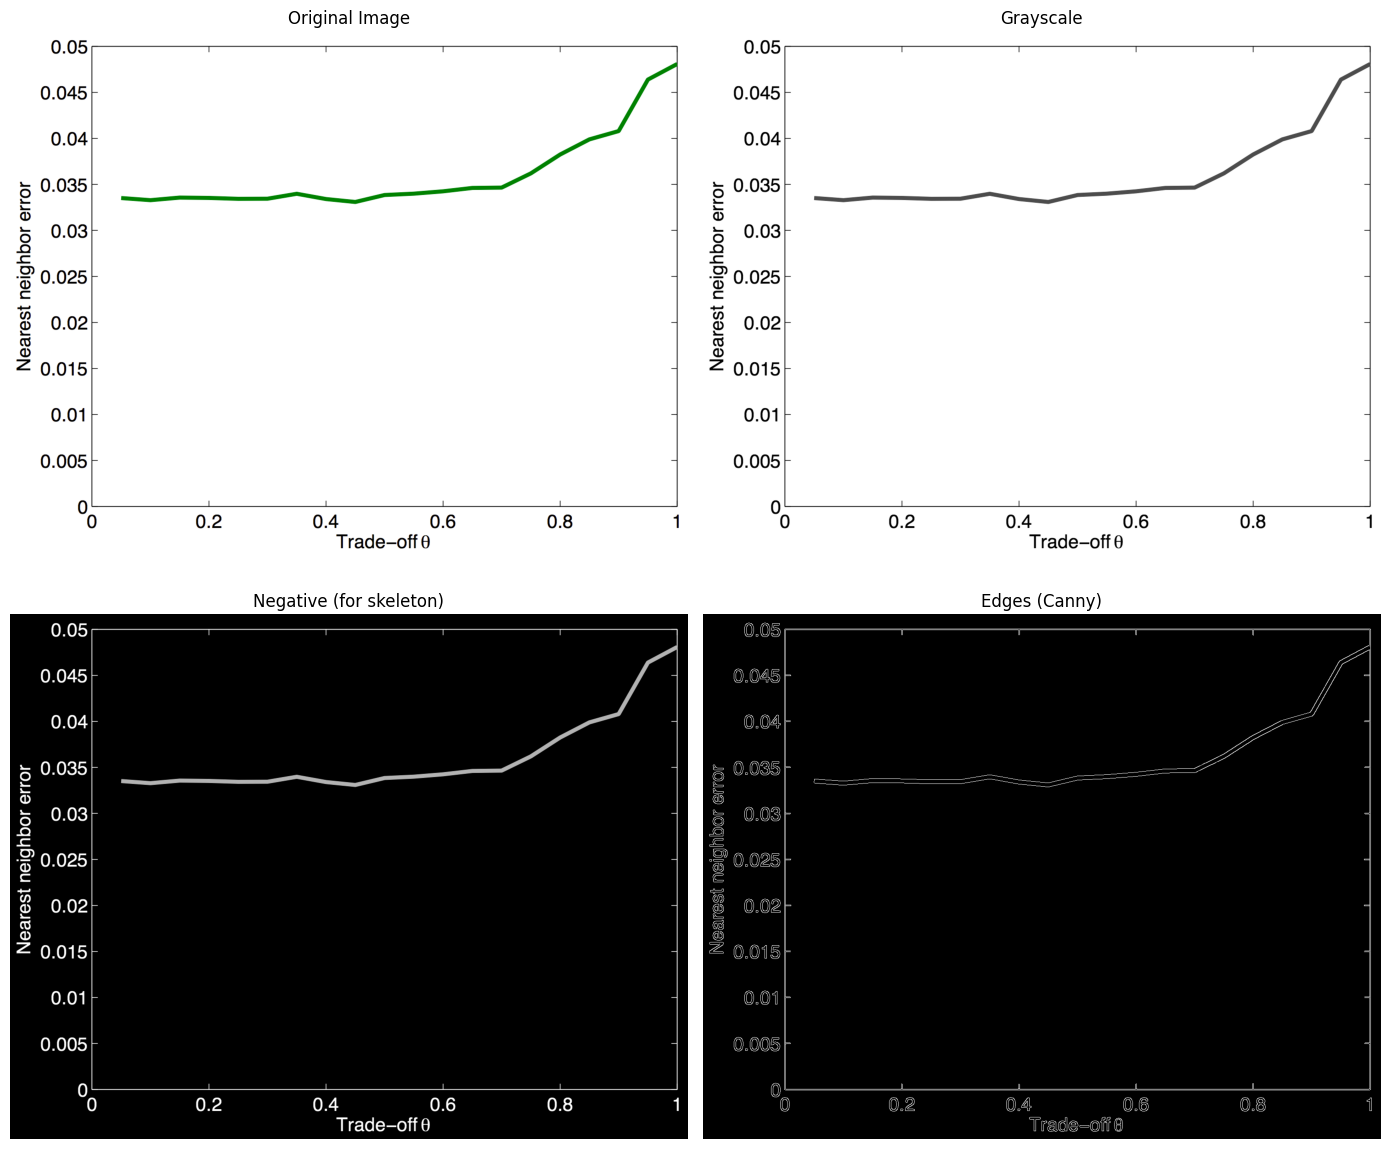

In [9]:
if image_path:
    # Load and process for visualization
    img_cv = cv2.imread(str(image_path))
    img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
    
    # Create visualization grid
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    
    # Original
    axes[0, 0].imshow(img_rgb)
    axes[0, 0].set_title("Original Image")
    axes[0, 0].axis('off')
    
    # Grayscale
    gray = cv2.cvtColor(img_cv, cv2.COLOR_BGR2GRAY)
    axes[0, 1].imshow(gray, cmap='gray')
    axes[0, 1].set_title("Grayscale")
    axes[0, 1].axis('off')
    
    # Negative
    negative = 255 - gray
    axes[1, 0].imshow(negative, cmap='gray')
    axes[1, 0].set_title("Negative (for skeleton)")
    axes[1, 0].axis('off')
    
    # Edge detection
    edges = cv2.Canny(gray, 50, 150)
    axes[1, 1].imshow(edges, cmap='gray')
    axes[1, 1].set_title("Edges (Canny)")
    axes[1, 1].axis('off')
    
    plt.tight_layout()
    plt.show()

## Next Steps

Explore individual stages in detail:

1. **Stage 1**: `01_stage1_ingestion.ipynb` - PDF/Image loading
2. **Stage 2**: `02_stage2_detection.ipynb` - YOLO detection
3. **Stage 3**: `03_stage3_extraction.ipynb` - Full extraction with ResNet-18
4. **Stage 4**: `04_stage4_reasoning.ipynb` - Gemini API reasoning (NEW!)

## Pipeline Status

| Stage | Status | Accuracy |
| --- | --- | --- |
| Stage 1 | COMPLETE | N/A |
| Stage 2 | COMPLETE | 85%+ mAP |
| Stage 3 | COMPLETE | 94.66% (ResNet-18) |
| Stage 4 | IN PROGRESS | Gemini API |
| Stage 5 | PLANNED | - |